# CPSR: Edge-of-Chaos Quantum Reservoir (QELM) in Qiskit

**Builds on:** `Quantum_Reservoir_Qiskit.ipynb`. Sections 0a and 0b below are
copied **verbatim, unchanged** from that notebook's "0a. Reservoir module" and
"0b. Benchmark Tasks" cells -- both the recurrent-reservoir and QELM code
paths, GPU/CPU and real-IBM-hardware execution, and the benchmark harness are
untouched. Nothing in this notebook edits, wraps, or reimplements any of that
code; later sections only call it with different arguments.

**What this notebook studies:** the reservoir's **QELM (Quantum Extreme
Learning Machine) architecture** -- `run_reservoir_qelm` / `build_qelm_circuit`
in Section 0a -- as a function of its own entangling coupling `g` and depth
`reps` (the arguments QELM takes directly; note these are independent of
`ReservoirConfig.g`/`.reps`, which only the *recurrent* architecture reads).
QELM resets every qubit each step and re-encodes a classical sliding window, so
(per Section 0a's own module docstring) it is a **memoryless quantum feature
map**, not a memory-retaining reservoir -- this notebook does not claim
otherwise.

Three things are added on top of the unchanged Sections 0a/0b:

1. **Edge-of-chaos diagnostics** (Sections 2-3) of QELM's per-step entangling
   layer -- the exact same `reservoir_layer` function Section 0a's
   `build_qelm_circuit` calls -- via operator-entanglement entropy, an
   out-of-time-order-correlator (OTOC) scrambling time, and the adjacent-gap
   ratio `<r>` compared against numerically-calibrated Poisson/COE/CUE
   reference ensembles. All three are unit-tested (Section 3) before any sweep
   is trusted, including a regression test that the diagnostics' numpy unitary
   reproduces the ACTUAL Aer QELM circuit's statevector to machine precision.
2. **Performance impact** (Section 5): the SAME task functions from the
   unchanged Section 0b (`task_kpauli`, `task_narma2`, `memory_capacity`,
   `chrono_split`, `select_and_eval_ridge`) are evaluated on QELM output swept
   across the same coupling grid as the diagnostics, and correlated with them
   quantitatively (Pearson r, p-values). `run_benchmark`'s convenience wrapper
   is not used for this sweep, because it always calls `run_reservoir_qelm`
   with QELM's *default* `g=0.05, reps=1` and has no parameter to sweep them
   (unchanged Section 0b -- nothing there tries to solve a problem it was not
   built for); the sweep instead calls `run_reservoir_qelm` and the individual
   Section 0b task/metric functions directly, exactly as `run_benchmark`'s own
   body does internally.
3. **A finite-size check** (Section 6) of the same spectral-statistics
   diagnostic at N=6, 8, 10, reported honestly rather than asserted.

**No classical-shadow readout is implemented in this notebook.** All features
are read out exactly (Section 0a's `save_expectation_value`, noiseless by
construction), matching Section 0a's own module docstring:
*"EXACT expectation-value readout ... no classical-shadow / randomized-
measurement estimation."*

**Compliance with `CPSR_Code_Review_Response.md`:** since the reservoir and
benchmark code are inherited unchanged from `Quantum_Reservoir_Qiskit.ipynb`,
every review comment that notebook already resolved (memory-capacity leakage,
train/test leakage, backend pinning, credential handling, one-source-of-truth
circuit construction, etc.) remains resolved here by construction. Comments
specific to the classical-shadow estimator (4, 5, 6, 11) are not applicable --
this notebook implements no shadow readout. Section 7's compliance map gives
the full comment-by-comment accounting.


## Setup

In [1]:
USE_GPU = True
USE_QPU = False   

In [2]:
!pip install qiskit-ibm-runtime
if USE_GPU:
    !nvidia-smi
    !pip install -U qiskit qiskit-aer-gpu-cu11
else:
    !pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 122.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 45.3 MB/s eta 0:00:00
Tue Sep  8 02:09:46 2026       
+---------------------------------------------------------------------

In [3]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
print(sim.available_devices())

('CPU', 'GPU')


In [4]:
from __future__ import annotations

import functools
import itertools
import os
import time
from dataclasses import dataclass
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, unitary_group

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Pauli, Operator, Statevector

import qiskit
import qiskit_aer  # noqa: F401  -- import needed to register .save_expectation_value on QuantumCircuit
from qiskit_aer import AerSimulator

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

print('numpy', np.__version__, ' scipy', __import__('scipy').__version__)
print('qiskit', qiskit.__version__, ' qiskit-aer', qiskit_aer.__version__)


numpy 2.1.3  scipy 1.16.3
qiskit 2.5.2  qiskit-aer 0.17.2


## Section 0a -- Reservoir module (verbatim, unchanged, from `Quantum_Reservoir_Qiskit.ipynb`)

Copied exactly as written there -- recurrent architecture, QELM architecture,
CPU/GPU execution, and real-IBM-hardware execution for both, including that
notebook's own module docstring and scope note below.


In [5]:
"""
This module implements *only* the reservoir itself:
  - ONE fixed *nearest-neighbor-chain topology (no topology sweep/optimization)*
  - ONE fixed coupling strength `g` (no "edge of chaos" / critical-phase scan;
    g is just a hyperparameter you can tune, with no special physical claim
    attached to any particular value)
  - EXACT expectation-value readout, computed directly by Aer's
    `save_expectation_value` (no classical-shadow / randomized-measurement
    estimation)
"""

# =============================================================================
# 1. Reservoir configuration and circuit construction
# =============================================================================

def chain_edges(N: int):
    """Nearest-neighbor chain -- the one fixed topology used throughout."""
    return [(i, i + 1) for i in range(N - 1)]


@dataclass
class ReservoirConfig:
    N: int = 6                     # <-- INCREASE QUBIT COUNT HERE
    g: float = 0.6                 # entangling coupling angle (radians), fixed
    reps: int = 2                  # entangling+disorder block repetitions per timestep
    input_qubit: int = 0           # qubit reset + re-encoded with u_t every step
    seed: int = 42                 # fixes the random disorder (bias_z, bias_x)

    # `g` and `reps` above were picked by a one-time check of validation-block
    # NRMSE across a small grid (g in {0.3,0.6,0.94,1.2,1.57} rad x reps in
    # {1,2,3}), NOT by scanning for a claimed "critical"/"edge of chaos" point
    # and NOT swept per-experiment -- see the module docstring's SCOPE note.

    def sample_disorder(self):
        rng = np.random.RandomState(self.seed)
        bias_z = rng.uniform(0, 2 * np.pi, self.N)
        bias_x = rng.uniform(0.3, 0.7, self.N)
        return bias_z, bias_x


def reservoir_layer(qc: QuantumCircuit, N: int, g: float, bias_z, bias_x):
    """One entangling + disorder layer on the fixed chain topology.

    U = Rx(bias_x) . Rz(bias_z) . CPhase(2g)_chain, applied left-to-right as a
    circuit (so the entangling bricks go first). `g` is just a coupling
    strength here -- not swept, not framed as a phase transition.
    """
    for a, b in chain_edges(N):
        qc.cp(2.0 * g, a, b)
    for i in range(N):
        qc.rz(bias_z[i], i)
    for i in range(N):
        qc.rx(bias_x[i], i)


def feature_ops(N: int, input_qubit: int):
    """Local Pauli readout operators: X/Y/Z on every memory qubit (everything
    except `input_qubit`) plus nearest-neighbor ZZ correlators among them.

    These are read out EXACTLY (Aer computes them directly from the
    statevector/density matrix) -- there is no shot noise and no classical-
    shadow estimator here. That is a deliberate simplification: this module
    benchmarks the reservoir's computational quality, not a shot-limited
    hardware read-out protocol.
    """
    mem = [q for q in range(N) if q != input_qubit]
    ops, labels = [], []
    for q in mem:
        for name in ('Z', 'X', 'Y'):
            ops.append((Pauli(name), [q]))
            labels.append(f'{name}{q}')
    for a, b in zip(mem[:-1], mem[1:]):
        ops.append((Pauli('ZZ'), [a, b]))
        labels.append(f'Z{a}Z{b}')
    return labels, ops


def build_trajectory_circuit(cfg: ReservoirConfig, u_seq: Sequence[float]):
    """Build ONE circuit for the entire recurrent trajectory.

    Each timestep: reset the input qubit (discard its old state -> fading
    memory), inject u_t via a Ry rotation, apply the reservoir layer(s), and
    snapshot every feature's exact expectation value with a labeled
    `save_expectation_value`. The memory register is never reset, so its
    state at step t carries forward everything the unitary dynamics retained
    from steps < t.

    Doing the whole trajectory as one circuit (rather than T separate Python-
    level evolve() calls) lets the entire recurrence run inside Aer's C++/CUDA
    engine in a single `.run()` call -- which is what makes the GPU device
    switch in `run_reservoir` actually matter for wall-clock time.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops(cfg.N, cfg.input_qubit)
    qc = QuantumCircuit(cfg.N)
    for t, u_t in enumerate(u_seq):
        qc.reset(cfg.input_qubit)
        qc.ry(np.pi * float(u_t), cfg.input_qubit)
        for _ in range(cfg.reps):
            reservoir_layer(qc, cfg.N, cfg.g, bias_z, bias_x)
        for (op, qargs), lab in zip(ops, labels):
            qc.save_expectation_value(op, qargs, label=f'{lab}__t{t}')
    return qc, labels


# =============================================================================
# 2a. CPU/GPU execution
# =============================================================================

def make_simulator(use_gpu: bool = False, method: str = 'density_matrix') -> AerSimulator:
    """Build the Aer backend. This is the ONLY place device selection happens.

    `method='density_matrix'` is required for the reset-based fading-memory
    architecture above (resetting one qubit of an entangled *pure* state
    produces a mixed state in general, so a plain Statevector cannot represent
    it -- see the SCALING NOTES below for the statevector-only alternative and
    what it costs you).
    """
    device = 'GPU' if use_gpu else 'CPU'
    if use_gpu:
        # Gotcha: AerSimulator(device='GPU').available_devices() just ECHOES
        # BACK the device it was already configured with -- it does not
        # actually probe hardware/build support (verified empirically; see
        # notebook Section 2). The only reliable check is to ask a freshly
        # constructed, unconfigured simulator what it truly supports.
        available = AerSimulator().available_devices()
        if 'GPU' not in available:
            raise RuntimeError(
                "USE_GPU=True but this qiskit-aer build has no GPU device "
                f"(available devices on a fresh AerSimulator(): {available}).\n"
                "qiskit-aer's PyPI wheels for Windows are CPU-only. To get the GPU "
                "device you need either:\n"
                f"  (a) WSL2 / native Linux + `pip install qiskit-aer-gpu-cu11` "
                f"(matches this repo's qiskit-aer=={qiskit_aer.__version__}), or\n"
                "  (b) build qiskit-aer from source against your local CUDA toolkit "
                "(see qiskit.org/ecosystem/aer build docs).\n"
                "Set USE_GPU = False to run on CPU in the meantime."
            )
    return AerSimulator(method=method, device=device)


def run_reservoir(cfg: ReservoirConfig, u_seq: Sequence[float], use_gpu: bool = False,
                   use_qpu: bool = False, method: str = 'density_matrix', **qpu_kwargs):
    """Execute the full recurrent trajectory once. Returns (labels, X, info).

    X has shape (T, n_features); info carries timing + circuit-resource data
    so CPU vs GPU vs QPU (or N vs N') runs can be compared honestly.

    `use_qpu=True` routes to `run_reservoir_qpu` (real IBM hardware) instead
    of Aer -- a genuinely different execution path, not just a device string;
    see that function's docstring. `**qpu_kwargs` (backend_name, service,
    shots, optimization_level, max_circuits) are forwarded to it and ignored
    otherwise.
    """
    # if use_qpu:
    #     return run_reservoir_qpu(cfg, u_seq, **qpu_kwargs)

    qc, labels = build_trajectory_circuit(cfg, u_seq)
    sim = make_simulator(use_gpu=use_gpu, method=method)
    tqc = transpile(qc, sim)

    t0 = time.perf_counter()
    result = sim.run(tqc, shots=1).result()
    elapsed = time.perf_counter() - t0

    data = result.data(0)
    T = len(u_seq)
    X = np.empty((T, len(labels)))
    for t in range(T):
        for j, lab in enumerate(labels):
            X[t, j] = np.real(data[f'{lab}__t{t}'])

    info = {
        'device': 'GPU' if use_gpu else 'CPU',
        'method': method,
        'N': cfg.N,
        'T': T,
        'elapsed_s': elapsed,
        'steps_per_s': T / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth': tqc.depth(),
        'circuit_size': tqc.size(),
        'n_features': len(labels),
    }
    return labels, X, info


# =============================================================================
# 2b. Real IBM hardware execution (USE_QPU)
# =============================================================================
# This is a genuinely different code path from CPU/GPU, not a device swap:
# Aer's `save_expectation_value` (Section 2) is a SIMULATOR-ONLY instruction
# that snapshots mid-circuit state without collapsing it -- real QPUs have no
# such thing, and cannot persist a quantum state between separate circuit
# executions the way one big Aer circuit does across T reset-and-continue
# steps. So on real hardware, the state at step t has to be recreated from
# scratch by literally replaying the ENTIRE prefix u_1..u_t inside ONE
# circuit that ends with an end-of-circuit expectation-value read via the
# Estimator primitive. Circuit depth for step t is O(t); summed over a
# T-step trajectory that is O(T^2) total gates -- which is why `max_circuits`
# below defaults small and a hardware run should use a much shorter T than
# the CPU/GPU benchmarks in this module use.

DEFAULT_QPU_BACKEND = 'ibm_marrakesh'

def get_ibm_service() -> 'QiskitRuntimeService':
    """Authenticate against IBM Quantum ONLY from environment variables --
    never hard-code a token or CRN here or in a notebook (review comment 13).

    Reads:
        IBM_QUANTUM_TOKEN     your IBM Cloud API token
        IBM_QUANTUM_INSTANCE  your IBM Cloud CRN (Cloud Resource Name) for the
                               Quantum Compute service instance

    Set these in your shell -- e.g. on Windows:
        setx IBM_QUANTUM_TOKEN "..."
        setx IBM_QUANTUM_INSTANCE "crn:v1:bluemix:public:quantum-computing:..."
    (restart your shell/kernel afterwards) -- or on Linux/macOS:
        export IBM_QUANTUM_TOKEN=...
        export IBM_QUANTUM_INSTANCE=crn:...

    This function does NOT call `QiskitRuntimeService.save_account(...)` --
    it authenticates in-memory for this process only, so nothing is written
    to disk beyond what you already put in your environment. If you'd rather
    persist an account to Qiskit's config store, call `save_account` yourself
    (see the qiskit-ibm-runtime docs); that is a deliberate choice this
    module leaves to you rather than doing on your behalf.
    """
    token = os.environ.get('IBM_QUANTUM_TOKEN')
    instance = os.environ.get('IBM_QUANTUM_INSTANCE')
    if not token or not instance:
        missing = [n for n, v in (('IBM_QUANTUM_TOKEN', token), ('IBM_QUANTUM_INSTANCE', instance)) if not v]
        raise RuntimeError(
            "USE_QPU=True requires IBM Quantum credentials as environment variables "
            f"-- missing: {', '.join(missing)}.\n"
            "Set IBM_QUANTUM_TOKEN (your IBM Cloud API token) and IBM_QUANTUM_INSTANCE "
            "(your IBM Cloud CRN for the Quantum Compute service instance), then restart "
            "your shell/notebook kernel. Credentials are never hard-coded in this repo "
            "(review comment 13)."
        )
    from qiskit_ibm_runtime import QiskitRuntimeService
    return QiskitRuntimeService(channel='ibm_quantum_platform', token=token, instance=instance)


def _pauli_to_sparse_op(N: int, pauli: Pauli, qargs):
    """Convert one `feature_ops`-style (Pauli, qargs) pair into an N-qubit
    `SparsePauliOp`, for the Estimator primitive (identity elsewhere)."""
    from qiskit.quantum_info import SparsePauliOp
    return SparsePauliOp.from_sparse_list([(pauli.to_label(), qargs, 1.0)], num_qubits=N)


def build_hardware_circuits(cfg: ReservoirConfig, u_seq: Sequence[float]):
    """One circuit per timestep t, each replaying the FULL prefix u_1..u_t
    from |0..0> (see the section note above for why). Returns
    (circuits, observables, labels) -- `observables` is shared across all
    circuits (same feature set every step); `labels[j]` names
    `observables[j]`.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops(cfg.N, cfg.input_qubit)
    observables = [_pauli_to_sparse_op(cfg.N, op, qargs) for (op, qargs) in ops]

    circuits = []
    for t in range(1, len(u_seq) + 1):
        qc = QuantumCircuit(cfg.N)
        for u_t in u_seq[:t]:
            qc.reset(cfg.input_qubit)
            qc.ry(np.pi * float(u_t), cfg.input_qubit)
            for _ in range(cfg.reps):
                reservoir_layer(qc, cfg.N, cfg.g, bias_z, bias_x)
        circuits.append(qc)
    return circuits, observables, labels


def run_reservoir_qpu(cfg: ReservoirConfig, u_seq: Sequence[float],
                       backend_name: str = DEFAULT_QPU_BACKEND, service=None,
                       shots: int = 4096, optimization_level: int = 3,
                       max_circuits: int = 25):
    """Run the recurrent trajectory on a real IBM QPU (default: `ibm_marrakesh`,
    pinned by name -- no silent `least_busy()` substitution, per comment 9).

    `max_circuits` is a deliberate, small default safety cap: each extra
    timestep is a full prefix-replay circuit (see the section note above), so
    T timesteps cost O(T^2) total two-qubit gates on a real, rate/cost-limited
    device. Raise it explicitly if you really want a longer run.

    Returns (labels, X, info); `info` reports backend name/version, job id,
    per-circuit depth and two-qubit-gate count (growing with t), and total
    two-qubit gates across the whole job, so the hardware cost of this run is
    visible rather than hidden (comment 9-11's spirit: report real resources).
    """
    if len(u_seq) > max_circuits:
        raise ValueError(
            f"len(u_seq)={len(u_seq)} exceeds max_circuits={max_circuits}. Real hardware "
            "cost grows O(T^2) here (see run_reservoir_qpu's docstring) -- this cap exists "
            "so a long T isn't submitted to paid/rate-limited hardware by accident. Pass a "
            "larger max_circuits explicitly if you intend that."
        )

    from qiskit_ibm_runtime import EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = service or get_ibm_service()
    backend = service.backend(backend_name)

    circuits, observables, labels = build_hardware_circuits(cfg, u_seq)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=optimization_level)
    isa_circuits = [pm.run(qc) for qc in circuits]
    isa_observables = [[obs.apply_layout(ic.layout) for obs in observables] for ic in isa_circuits]
    pubs = list(zip(isa_circuits, isa_observables))

    estimator = EstimatorV2(mode=backend)
    estimator.options.default_shots = shots

    t0 = time.perf_counter()
    job = estimator.run(pubs)
    result = job.result()
    elapsed = time.perf_counter() - t0

    X = np.array([np.real(pub_result.data.evs) for pub_result in result])

    depths = [ic.depth() for ic in isa_circuits]
    twoq_counts = [sum(v for k, v in ic.count_ops().items() if k in ('cz', 'ecr', 'cx', 'rzz'))
                   for ic in isa_circuits]
    info = {
        'device': 'QPU', 'backend': backend.name,
        'backend_num_qubits': backend.num_qubits,
        'job_id': job.job_id(),
        'N': cfg.N, 'T': len(u_seq), 'shots': shots,
        'elapsed_s': elapsed,
        'steps_per_s': len(u_seq) / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth_per_step': depths,
        'circuit_depth_final': depths[-1] if depths else 0,
        'two_qubit_gates_per_step': twoq_counts,
        'two_qubit_gates_total': int(sum(twoq_counts)),
        'n_features': len(labels),
    }
    return labels, X, info


# =============================================================================
# 2c. Memoryless QELM execution (SCALING NOTE option 1: statevector, higher N)
# =============================================================================
# Sections 1-2b above are the genuinely recurrent architecture: ONE qubit
# (`input_qubit`) is reset and re-encoded each step while the rest of the
# register is never reset, so the state is generally MIXED and needs Aer's
# method='density_matrix' (4**N cost). This section drops that: reset EVERY
# qubit each step (so the state stays PURE and method='statevector', 2**N
# cost, becomes valid -- roughly doubling the reachable N for the same memory
# budget), and recover "memory" only from re-encoding a classical sliding
# window of recent inputs. This is a Quantum Extreme Learning Machine (QELM):
# a memoryless feature map, not a memory -- any nonzero memory-capacity score
# from it reflects the classical window, NOT information retained by the
# quantum state (contrast with comment 1's fix in Section 1). Same
# window/slot-phase scheme as `idcpsr_qiskit.py`'s `reservoir_states_qiskit`,
# reimplemented here as one Aer circuit with exact `save_expectation_value`
# readout so it plugs into the same benchmark harness (Section 0b) as the
# recurrent reservoir above.

def feature_ops_all(N: int, max_weight: int = 3):
    """Local Pauli readout operators: the FULL 3**w Pauli-string basis
    (every combination of X/Y/Z, not just all-Z) on every adjacent window of
    w<=max_weight qubits, for w=1 (every qubit) up through w=max_weight
    (every adjacent w-tuple).

    Why the full basis, not just Z/ZZ/ZZZ: after `build_qelm_circuit`'s
    per-step disorder rotation (bias_z, bias_x, fixed but qubit-specific), a
    single qubit's Bloch vector is a FIXED rotation of (sin(theta), 0,
    cos(theta)), so <Z> alone is no longer cos(theta) -- but <X>, <Y>, <Z>
    TOGETHER remain an exactly invertible linear image of (sin(theta),
    cos(theta)) for any fixed rotation. The same holds jointly for a
    w-qubit PRODUCT state: <P1 P2 ... Pw> for the right combination of
    Paulis linearly spans everything needed to reconstruct
    prod_j cos(theta_j) via ridge -- but only if enough of the 3**w
    combinations are actually read out. Reading out only the all-Z
    correlator (as an earlier version of this function did) discards most of
    that span, which is exactly why k-Pauli tasks with k>=2 fit poorly
    without this: see `run_reservoir_qelm`'s docstring for the empirical
    comparison. `max_weight=3` matches this module's k-Pauli benchmark's
    `k_list=(1,2,3)` -- no higher-weight terms are needed for k<=3, so none
    are computed.
    """
    ops, labels = [], []
    paulis = ('Z', 'X', 'Y')
    for q in range(N):
        for name in paulis:
            ops.append((Pauli(name), [q]))
            labels.append(f'{name}{q}')
    if max_weight >= 2:
        for a, b in zip(range(N - 1), range(1, N)):
            for p1, p2 in itertools.product(paulis, repeat=2):
                ops.append((Pauli(p1 + p2), [a, b]))
                labels.append(f'{p1}{a}{p2}{b}')
    if max_weight >= 3:
        for a in range(N - 2):
            for p1, p2, p3 in itertools.product(paulis, repeat=3):
                ops.append((Pauli(p1 + p2 + p3), [a, a + 1, a + 2]))
                labels.append(f'{p1}{a}{p2}{a + 1}{p3}{a + 2}')
    return labels, ops


def build_qelm_circuit(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                        max_weight: int = 3, reps: int = 1, g: float = 0.05):
    """Build ONE circuit for the entire trajectory, memoryless-QELM style.

    Each timestep: reset ALL N qubits to |0..0> (not just `input_qubit` as in
    `build_trajectory_circuit`), so the state is pure going into every step's
    encoding. `u_t` is placed into a length-min(window_size, N) sliding
    window of the most recent inputs, mapped 1:1 onto qubits 0..window-1 (NOT
    `w % N` -- wrapping onto qubits that already hold a different lag would
    ADD the two lags' rotation angles together on the same qubit, corrupting
    both; capping the window at N and dropping older lags instead keeps every
    retained lag on its own qubit). Then `reps` reservoir layers (using `g`,
    NOT `cfg.g`/`cfg.reps` -- see below) are applied and every feature's
    exact expectation value is snapshotted, exactly as in
    `build_trajectory_circuit`.

    `reps`/`g` are QELM's OWN entangling depth/strength, deliberately
    decoupled from `cfg.reps`/`cfg.g` (which the genuinely recurrent
    architecture in Section 1 uses): a validation-block sweep (same one-time
    grid-check spirit as `ReservoirConfig`'s own `g`/`reps` choice) over
    reps in {0,1,2,3} x g in {0, 0.05, ..., 0.6} found that MORE entangling
    here actively HURTS the k-Pauli tasks -- each `reservoir_layer` rotates
    every qubit's Bloch vector by more disorder, widening the gap between
    what `feature_ops_all`'s finite (weight<=3) Pauli-string basis can
    linearly represent and the target's exact trigonometric form. `reps=1,
    g=0.05` was the smallest step past `reps=0` (which reduces to a purely
    classical, exactly-solvable cosine-product feature map -- see
    `run_reservoir_qelm`'s docstring) that still exercises genuine multi-qubit
    entangling gates while keeping k-Pauli NRMSE robustly low (not merely
    low on one lucky ridge-alpha tie-break) across N=4..10.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops_all(cfg.N, max_weight=max_weight)
    eff_window = min(window_size, cfg.N)
    slot_to_qubit = list(range(eff_window))

    qc = QuantumCircuit(cfg.N)
    for t, _ in enumerate(u_seq):
        lo = max(0, t - eff_window + 1)
        wlen = t - lo + 1
        window = np.zeros(eff_window)
        window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(cfg.N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * float(uu)

        for i in range(cfg.N):
            qc.reset(i)
            qc.ry(per_q[i], i)
        for _ in range(reps):
            reservoir_layer(qc, cfg.N, g, bias_z, bias_x)
        for (op, qargs), lab in zip(ops, labels):
            qc.save_expectation_value(op, qargs, label=f'{lab}__t{t}')
    return qc, labels


def run_reservoir_qelm(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                        max_weight: int = 3, reps: int = 1, g: float = 0.05,
                        use_gpu: bool = False, use_qpu: bool = False,
                        method: str = 'statevector', **qpu_kwargs):
    """Execute the memoryless QELM trajectory once. Same (labels, X, info)
    return shape as `run_reservoir`, so it drops into the same benchmark
    harness (`run_benchmark(..., reservoir_fn=...)`).

    `method='statevector'` is the point of this variant (see SCALING NOTES) --
    passing `method='density_matrix'` still works (a full per-step reset
    keeps the state pure either way) but gives up the 2**N-vs-4**N memory
    saving that is the whole reason to use it.

    `reps`/`g` (QELM's own entangling depth/strength, default 1/0.05 --
    see `build_qelm_circuit`'s docstring) trade off against k-Pauli accuracy:
    `reps=0` (no entangling at all) makes this an EXACTLY solvable, purely
    classical cosine-product feature map (k-Pauli NRMSE -> 0 for k<=max_weight,
    but zero genuine quantum computation happens); the shipped defaults are
    the smallest step past that which still runs real entangling gates while
    keeping k-Pauli NRMSE robustly low (see the module's benchmark results).
    Raising `g`/`reps` back toward `cfg.g`/`cfg.reps` (0.6/2, used by the
    recurrent architecture) measurably degrades k-Pauli fits -- more
    disorder-rotation per step widens the gap between what the finite
    (`max_weight`-bounded) Pauli-string readout can linearly represent and
    the target's exact trigonometric form.

    `use_qpu=True` routes to `run_reservoir_qelm_qpu` (real IBM hardware)
    instead of Aer, mirroring `run_reservoir`'s `use_qpu` dispatch.
    `**qpu_kwargs` (backend_name, service, shots, optimization_level,
    max_circuits) are forwarded to it and ignored otherwise.
    """
    if use_qpu:
        return run_reservoir_qelm_qpu(cfg, u_seq, window_size=window_size, max_weight=max_weight,
                                       reps=reps, g=g, **qpu_kwargs)

    qc, labels = build_qelm_circuit(cfg, u_seq, window_size=window_size, max_weight=max_weight,
                                     reps=reps, g=g)
    sim = make_simulator(use_gpu=use_gpu, method=method)
    tqc = transpile(qc, sim)

    t0 = time.perf_counter()
    result = sim.run(tqc, shots=1).result()
    elapsed = time.perf_counter() - t0

    data = result.data(0)
    T = len(u_seq)
    X = np.empty((T, len(labels)))
    for t in range(T):
        for j, lab in enumerate(labels):
            X[t, j] = np.real(data[f'{lab}__t{t}'])

    info = {
        'device': 'GPU' if use_gpu else 'CPU',
        'method': method,
        'architecture': 'qelm_statevector',
        'window_size': window_size,
        'N': cfg.N,
        'T': T,
        'elapsed_s': elapsed,
        'steps_per_s': T / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth': tqc.depth(),
        'circuit_size': tqc.size(),
        'n_features': len(labels),
    }
    return labels, X, info


# -----------------------------------------------------------------------------
# 2d. QELM real IBM hardware execution (USE_QPU)
# -----------------------------------------------------------------------------
# The recurrent architecture's hardware path (Section 2b) has to replay the
# ENTIRE input prefix u_1..u_t inside one circuit per timestep, because Aer's
# mid-circuit save_expectation_value has no real-hardware equivalent and a
# real QPU cannot persist a quantum state between circuit executions -- hence
# O(t) depth per step, O(T^2) total gates. The QELM architecture does NOT
# have that problem: every qubit is reset each step anyway (see
# `build_qelm_circuit`), so the state at step t depends ONLY on the current
# `window_size`-wide window, not on anything before it. Each hardware circuit
# below is therefore a single fresh encode-then-reservoir-layers circuit --
# CONSTANT depth in t, O(T) total gates across the whole trajectory, no
# prefix replay needed.

def build_qelm_hardware_circuits(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                                  max_weight: int = 3, reps: int = 1, g: float = 0.05):
    """One circuit per timestep t for the QELM variant on real hardware.
    Unlike `build_hardware_circuits` (recurrent architecture), no prefix
    replay is needed -- see the section note above. Same no-aliasing window
    mapping, full-Pauli-string readout (`feature_ops_all`, `max_weight`), and
    `reps`/`g` defaults as `build_qelm_circuit` -- see its docstring. Returns
    (circuits, observables, labels), same shape as `build_hardware_circuits`.

    Note: `max_weight=3`'s full Pauli-string basis means many more distinct
    observables per circuit than the earlier all-Z-only design (93-327 for
    N=4..10) -- `EstimatorV2` groups these into compatible measurement bases
    automatically, but real-hardware jobs cost more (more distinct bases to
    sample) than a smaller observable set would.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops_all(cfg.N, max_weight=max_weight)
    observables = [_pauli_to_sparse_op(cfg.N, op, qargs) for (op, qargs) in ops]
    eff_window = min(window_size, cfg.N)
    slot_to_qubit = list(range(eff_window))

    circuits = []
    for t in range(len(u_seq)):
        lo = max(0, t - eff_window + 1)
        wlen = t - lo + 1
        window = np.zeros(eff_window)
        window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(cfg.N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * float(uu)

        qc = QuantumCircuit(cfg.N)
        for i in range(cfg.N):
            qc.ry(per_q[i], i)
        for _ in range(reps):
            reservoir_layer(qc, cfg.N, g, bias_z, bias_x)
        circuits.append(qc)
    return circuits, observables, labels


def run_reservoir_qelm_qpu(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                            max_weight: int = 3, reps: int = 1, g: float = 0.05,
                            backend_name: str = DEFAULT_QPU_BACKEND, service=None,
                            shots: int = 4096, optimization_level: int = 3,
                            max_circuits: int = 200):
    """Run the QELM trajectory on a real IBM QPU (default `ibm_marrakesh`,
    pinned by name, per comment 9 -- same convention as `run_reservoir_qpu`).

    `max_circuits` is still a safety cap (this submits one job with one
    circuit per timestep), but -- unlike the recurrent path's O(T^2) gate
    growth -- circuit depth here is CONSTANT in t (see the section note
    above), so a much larger T is reasonable at the same hardware cost.

    Returns (labels, X, info); `info` reports backend/job provenance and
    per-circuit depth/two-qubit-gate counts, same shape as
    `run_reservoir_qpu`'s `info` (comment 9-11's spirit: report real
    resources), plus `architecture`/`window_size` like `run_reservoir_qelm`.
    """
    if len(u_seq) > max_circuits:
        raise ValueError(
            f"len(u_seq)={len(u_seq)} exceeds max_circuits={max_circuits}. This cap exists "
            "so a long T isn't submitted to paid/rate-limited hardware by accident. Pass a "
            "larger max_circuits explicitly if you intend that."
        )

    from qiskit_ibm_runtime import EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = service or get_ibm_service()
    backend = service.backend(backend_name)

    circuits, observables, labels = build_qelm_hardware_circuits(cfg, u_seq, window_size=window_size,
                                                                   max_weight=max_weight, reps=reps, g=g)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=optimization_level)
    isa_circuits = [pm.run(qc) for qc in circuits]
    isa_observables = [[obs.apply_layout(ic.layout) for obs in observables] for ic in isa_circuits]
    pubs = list(zip(isa_circuits, isa_observables))

    estimator = EstimatorV2(mode=backend)
    estimator.options.default_shots = shots

    t0 = time.perf_counter()
    job = estimator.run(pubs)
    result = job.result()
    elapsed = time.perf_counter() - t0

    X = np.array([np.real(pub_result.data.evs) for pub_result in result])

    depths = [ic.depth() for ic in isa_circuits]
    twoq_counts = [sum(v for k, v in ic.count_ops().items() if k in ('cz', 'ecr', 'cx', 'rzz'))
                   for ic in isa_circuits]
    info = {
        'device': 'QPU', 'backend': backend.name,
        'backend_num_qubits': backend.num_qubits,
        'job_id': job.job_id(),
        'architecture': 'qelm_statevector', 'window_size': window_size,
        'N': cfg.N, 'T': len(u_seq), 'shots': shots,
        'elapsed_s': elapsed,
        'steps_per_s': len(u_seq) / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth_per_step': depths,
        'circuit_depth_final': depths[-1] if depths else 0,
        'two_qubit_gates_per_step': twoq_counts,
        'two_qubit_gates_total': int(sum(twoq_counts)),
        'n_features': len(labels),
    }
    return labels, X, info


## Section 0b -- Benchmark tasks (verbatim, unchanged, from `Quantum_Reservoir_Qiskit.ipynb`)

In [6]:
# =============================================================================
# 3. Benchmark tasks (repo-consistent + one literature-standard task)
# =============================================================================

def random_input(T: int, seed: int = 0) -> np.ndarray:
    return np.random.RandomState(seed).uniform(0, 1, T)


def task_kpauli(u: np.ndarray, k: int) -> np.ndarray:
    """y_t = prod_{j=1}^k cos(pi * u_{t-j})  -- nonlinear k-step memory task
    (identical definition to code/idcpsr.py's task_kpauli / task_kpauli in
    idcpsr_qiskit.py, kept for comparability with the rest of the repo)."""
    T = len(u)
    y = np.zeros(T)
    for t in range(k, T):
        y[t] = np.prod(np.cos(np.pi * u[t - k:t]))
    return y


def task_narma2(u: np.ndarray, u_scale: float = 0.5) -> np.ndarray:
    """Standard NARMA2 benchmark, a literature-standard (non-CPSR-specific)
    short-memory nonlinear task, useful as an external sanity check:
        y_t = 0.4 y_{t-1} + 0.4 y_{t-1} y_{t-2} + 0.6 (u_scale*u_t)^3 + 0.1

    The `u_scale` factor is standard practice for NARMA tasks (Appeltant et
    al. 2011): the recursive quadratic-ish term diverges if the driving
    signal has full [0,1] amplitude, so the literature drives NARMA with a
    lower-amplitude copy of the same input. The reservoir itself still sees
    the original, unscaled `u_t` -- only the regression *target* is defined
    on the rescaled signal, which changes nothing about what the reservoir
    can learn since the two are a fixed monotonic rescaling of each other.
    """
    T = len(u)
    y = np.zeros(T)
    us = u_scale * u
    for t in range(1, T):
        y_prev2 = y[t - 2] if t >= 2 else 0.0
        y[t] = 0.4 * y[t - 1] + 0.4 * y[t - 1] * y_prev2 + 0.6 * us[t] ** 3 + 0.1
    return y


def delay_target(u: np.ndarray, k: int) -> np.ndarray:
    """y_t = u_{t-k}  -- the delay task used by short-term memory capacity."""
    T = len(u)
    y = np.zeros(T)
    y[k:] = u[:T - k]
    return y


def delay_taps(u: np.ndarray, m: int) -> np.ndarray:
    """Classical-only control features: the raw last m+1 inputs, no quantum
    processing at all. Used as a baseline so a quantum-reservoir NRMSE win can
    be checked against "did the delayed input alone already explain this."""
    T = len(u)
    X = np.zeros((T, m + 1))
    for j in range(m + 1):
        X[j:, j] = u[:T - j]
    return X


# =============================================================================
# 4. Chronological split (review comment 8) + metrics
# =============================================================================

def chrono_split(T: int, washout: int, n_val: int, n_test: int, gap: int):
    """Chronological train/val/test split with a guard gap >= the longest lag
    any task in the suite looks back, on both sides of every boundary, so a
    training window can never overlap a validation/test target (the leakage
    review comment 8 flagged, fixed here by construction rather than by luck).
    """
    test = np.arange(T - n_test, T)
    val_end = T - n_test - gap
    val = np.arange(val_end - n_val, val_end)
    train_end = val_end - n_val - gap
    train = np.arange(washout, train_end)
    if len(train) < 10:
        raise ValueError(f'Not enough training points ({len(train)}) -- reduce '
                          f'washout/n_val/n_test/gap or increase T.')
    return train, val, test


def nrmse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2) / (np.var(y_true) + 1e-12)))


DEFAULT_ALPHAS = (1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)


def select_and_eval_ridge(X: np.ndarray, y: np.ndarray, train: np.ndarray, val: np.ndarray,
                           test: np.ndarray, alphas=DEFAULT_ALPHAS):
    """Ridge regularization strength `alpha` is selected on the VALIDATION
    block only; the test block is touched exactly once, after alpha is fixed
    (review comment 8 / "Additional methodological recommendations": separate
    model selection from final testing). Features are standardized using
    train-set statistics only.
    """
    scaler = StandardScaler().fit(X[train])
    Xtr, Xval, Xte = scaler.transform(X[train]), scaler.transform(X[val]), scaler.transform(X[test])

    best_alpha, best_val_err = alphas[0], np.inf
    for a in alphas:
        model = Ridge(alpha=a).fit(Xtr, y[train])
        err = nrmse(model.predict(Xval), y[val])
        if err < best_val_err:
            best_val_err, best_alpha = err, a

    model = Ridge(alpha=best_alpha).fit(Xtr, y[train])
    test_err = nrmse(model.predict(Xte), y[test])
    return test_err, best_alpha, model


def memory_capacity(X: np.ndarray, u: np.ndarray, train: np.ndarray, val: np.ndarray,
                     test: np.ndarray, k_max: int = 10, alphas=DEFAULT_ALPHAS):
    """Jaeger short-term memory capacity: MC = sum_k MC_k, MC_k = squared
    correlation between the true delayed input u_{t-k} and its ridge-regression
    reconstruction from reservoir features, capped at 1 per k. Because X here
    comes from the genuinely-recurrent reservoir (comment 1), a non-zero MC_k
    can only reflect information actually retained in the quantum state.
    Regularization is selected on `val`, exactly as in `select_and_eval_ridge`.
    """
    total = 0.0
    per_k = []
    for k in range(1, k_max + 1):
        y = delay_target(u, k)
        scaler = StandardScaler().fit(X[train])
        Xtr, Xval, Xte = scaler.transform(X[train]), scaler.transform(X[val]), scaler.transform(X[test])
        best_alpha, best_val_err = alphas[0], np.inf
        for a in alphas:
            model = Ridge(alpha=a).fit(Xtr, y[train])
            err = nrmse(model.predict(Xval), y[val])
            if err < best_val_err:
                best_val_err, best_alpha = err, a
        model = Ridge(alpha=best_alpha).fit(Xtr, y[train])
        pred = model.predict(Xte)
        y_test = y[test]
        cov = np.cov(pred, y_test)[0, 1] ** 2
        denom = np.var(y_test) * np.var(pred) + 1e-12
        v = float(np.clip(cov / denom, 0.0, 1.0))
        per_k.append(v)
        total += v
    return total, per_k


# =============================================================================
# 5. Benchmark harness
# =============================================================================


@dataclass
class BenchmarkResult:
    device: str
    N: int
    T: int
    reservoir_time_s: float
    steps_per_s: float
    circuit_depth: int
    circuit_size: int
    n_features: int
    mc_total: float
    mc_per_k: list
    kpauli_nrmse: dict
    kpauli_nrmse_classical: dict
    narma2_nrmse: float
    narma2_nrmse_classical: float
    fit_eval_time_s: float

from typing import Callable

def run_benchmark(cfg: ReservoirConfig, T: int = 600, washout: int = 50,
                   n_val: int = 100, n_test: int = 150, k_list=(1, 2, 3),
                   use_gpu: bool = False, use_qpu: bool = False, use_qelm: bool = False,
                   method: str = 'density_matrix', max_circuits: int = 25,
                   input_seed: int = 0) -> BenchmarkResult:
    if use_qelm:
        if use_qpu:
            return run_benchmark_qpu(cfg, T, washout, n_val, n_test, k_list, max_circuits, method, input_seed,
                                        run_reservoir_qelm_qpu)
        else:
            return run_benchmark_simulator(cfg, T, washout, n_val, n_test, k_list, use_gpu, method, input_seed, 
                                           run_reservoir_qelm)
    else:
        if use_qpu:
            return run_benchmark_qpu(cfg, T, washout, n_val, n_test, k_list, max_circuits, method, input_seed,
                                        run_reservoir_qpu)
        else:
            return run_benchmark_simulator(cfg, T, washout, n_val, n_test, k_list, use_gpu, method, input_seed, 
                                           run_reservoir)

def run_benchmark_simulator(cfg: ReservoirConfig, T: int = 600, washout: int = 50,
                   n_val: int = 100, n_test: int = 150, k_list=(1, 2, 3),
                   use_gpu: bool = False, method: str = 'density_matrix',
                   input_seed: int = 0, reservoir_fn: Callable = run_reservoir) -> BenchmarkResult:
    """Run the full benchmark suite (memory capacity + k-Pauli + NARMA2, each
    against a delay-line classical-only control) on one reservoir config.

    `reservoir_fn(cfg, u_seq, use_gpu=..., method=...) -> (labels, X, info)`
    defaults to `run_reservoir` (the genuinely recurrent architecture) but can
    be swapped for `run_reservoir_qelm` (Section 2c) to run this exact same
    harness against the memoryless QELM variant instead, for an
    apples-to-apples comparison -- `run_benchmark(cfg, ..., use_qelm=True)`
    (above) does this dispatch automatically.
    """

    u = random_input(T, seed=input_seed)
    labels, X, info = reservoir_fn(cfg, u, use_gpu=use_gpu, method=method)

    gap = max(max(k_list), 3) + 1  # guard gap >= longest lag any task looks back
    train, val, test = chrono_split(T, washout, n_val, n_test, gap)
    Xc = delay_taps(u, m=max(k_list))  # classical-only control features

    t0 = time.perf_counter()

    mc_total, mc_per_k = memory_capacity(X, u, train, val, test, k_max=max(8, max(k_list)))

    kpauli_nrmse, kpauli_nrmse_c = {}, {}
    for k in k_list:
        y = task_kpauli(u, k)
        kpauli_nrmse[k], _, _ = select_and_eval_ridge(X, y, train, val, test)
        kpauli_nrmse_c[k], _, _ = select_and_eval_ridge(Xc, y, train, val, test)

    y2 = task_narma2(u)
    narma2_nrmse, _, _ = select_and_eval_ridge(X, y2, train, val, test)
    narma2_nrmse_c, _, _ = select_and_eval_ridge(Xc, y2, train, val, test)

    fit_eval_time = time.perf_counter() - t0

    return BenchmarkResult(
        device=info['device'], N=cfg.N, T=T,
        reservoir_time_s=info['elapsed_s'], steps_per_s=info['steps_per_s'],
        circuit_depth=info['circuit_depth'], circuit_size=info['circuit_size'],
        n_features=info['n_features'],
        mc_total=mc_total, mc_per_k=mc_per_k,
        kpauli_nrmse=kpauli_nrmse, kpauli_nrmse_classical=kpauli_nrmse_c,
        narma2_nrmse=narma2_nrmse, narma2_nrmse_classical=narma2_nrmse_c,
        fit_eval_time_s=fit_eval_time,
    )


def run_benchmark_qpu(cfg: ReservoirConfig, T: int = 600, washout: int = 50,
                   n_val: int = 100, n_test: int = 150, k_list=(1, 2, 3),
                   max_circuits: int = 25, method: str = 'density_matrix', input_seed: int = 0,
                   reservoir_fn: Callable = run_reservoir_qpu) -> BenchmarkResult:
    """Run the full benchmark suite (memory capacity + k-Pauli + NARMA2, each
    against a delay-line classical-only control) on one reservoir config.
    """
    u = random_input(T, seed=input_seed)
    labels, X, info = reservoir_fn(cfg, u, max_circuits=max_circuits)

    gap = max(max(k_list), 3) + 1  # guard gap >= longest lag any task looks back
    train, val, test = chrono_split(T, washout, n_val, n_test, gap)
    Xc = delay_taps(u, m=max(k_list))  # classical-only control features

    t0 = time.perf_counter()

    mc_total, mc_per_k = memory_capacity(X, u, train, val, test, k_max=max(8, max(k_list)))

    kpauli_nrmse, kpauli_nrmse_c = {}, {}
    for k in k_list:
        y = task_kpauli(u, k)
        kpauli_nrmse[k], _, _ = select_and_eval_ridge(X, y, train, val, test)
        kpauli_nrmse_c[k], _, _ = select_and_eval_ridge(Xc, y, train, val, test)

    y2 = task_narma2(u)
    narma2_nrmse, _, _ = select_and_eval_ridge(X, y2, train, val, test)
    narma2_nrmse_c, _, _ = select_and_eval_ridge(Xc, y2, train, val, test)

    fit_eval_time = time.perf_counter() - t0

    return BenchmarkResult(
        device=info['device'], N=cfg.N, T=T,
        reservoir_time_s=info['elapsed_s'], steps_per_s=info['steps_per_s'],
        circuit_depth=info['circuit_depth_final'], circuit_size=info['two_qubit_gates_total'],
        n_features=info['n_features'],
        mc_total=mc_total, mc_per_k=mc_per_k,
        kpauli_nrmse=kpauli_nrmse, kpauli_nrmse_classical=kpauli_nrmse_c,
        narma2_nrmse=narma2_nrmse, narma2_nrmse_classical=narma2_nrmse_c,
        fit_eval_time_s=fit_eval_time,
    )



## Section 1 -- QELM configuration (quick demo)

In [7]:
N_QELM = 6
WINDOW_SIZE = 8
MAX_WEIGHT = 3
REPS_QELM = 2          # QELM's OWN depth (independent of ReservoirConfig.reps)
G_QELM_DEFAULT = 0.6   # QELM's OWN coupling (independent of ReservoirConfig.g) -- SWEPT below
RESERVOIR_SEED = 42

cfg_demo = ReservoirConfig(N=N_QELM, g=G_QELM_DEFAULT, reps=REPS_QELM, seed=RESERVOIR_SEED)
demo_qc, demo_labels = build_qelm_circuit(cfg_demo, random_input(3, seed=0), window_size=WINDOW_SIZE,
                                          max_weight=MAX_WEIGHT, reps=REPS_QELM, g=G_QELM_DEFAULT)
print(f'{cfg_demo.N} qubits, {len(demo_labels)} readout features/timestep '
      f'(window_size={WINDOW_SIZE}, max_weight={MAX_WEIGHT})')
print(cfg_demo)


6 qubits, 171 readout features/timestep (window_size=8, max_weight=3)
ReservoirConfig(N=6, g=0.6, reps=2, input_qubit=0, seed=42)


## Section 2 -- Edge-of-chaos diagnostics

Three physically independent diagnostics of QELM's per-step entangling layer --
`reservoir_layer(qc, N, g, bias_z, bias_x)`, the EXACT function `build_qelm_circuit`
(Section 0a) calls `reps` times every step, wrapped here as a numpy unitary via
Qiskit's own `Operator(...)` (one source of truth, regression-tested in Section 3):

1. **Operator-entanglement entropy `S_op(g)`** -- the von Neumann entropy of the
   layer's unitary under the Choi/vectorization isomorphism, bipartitioned
   across the middle of the chain. Zero exactly iff the layer is a product of
   single-qubit gates (`g=0`); grows toward its maximum as its entangling power
   increases.
2. **OTOC scrambling time `t*(g)`** -- the number of layers a local perturbation
   on qubit 0 needs before its out-of-time-order correlator with a distant
   qubit exceeds a fixed threshold (a "butterfly time" proxy) -- a genuine
   DYNAMICAL many-body-chaos test, independent of `S_op`'s algebraic measure.
3. **Adjacent-gap-ratio `<r>(g)`** -- the level-spacing-ratio statistic of the
   layer unitary's eigenphases (Floquet quasi-energies), compared against
   NUMERICALLY-CALIBRATED Poisson / COE / CUE reference distributions computed
   at the SAME Hilbert-space dimension (not memorized literature constants).

Reporting all three -- rather than picking whichever tells the nicest story --
is deliberate: an "edge of chaos" claim from a single, possibly-misleading
indicator is exactly what `CPSR_Code_Review_Response.md` comment 7 flagged.


In [8]:
def single_layer_unitary(N: int, g: float, bias_z, bias_x) -> np.ndarray:
    """The numpy unitary of ONE `reservoir_layer` call (Section 0a), built by
    wrapping that SAME function in Qiskit's own `Operator(...)` -- not a
    reimplementation. One-source-of-truth invariant, regression-tested in
    Section 3 against the actual QELM circuit."""
    qc = QuantumCircuit(N)
    reservoir_layer(qc, N, g, bias_z, bias_x)
    return Operator(qc).data


def step_unitary(N: int, g: float, reps: int, bias_z, bias_x) -> np.ndarray:
    """The full per-timestep unitary U_g^reps QELM actually applies every step
    (`reps` repeats of the one-layer Floquet operator, matching
    `build_qelm_circuit`'s own `for _ in range(reps): reservoir_layer(...)`)."""
    U1 = single_layer_unitary(N, g, bias_z, bias_x)
    return np.linalg.matrix_power(U1, reps)


def operator_entanglement(U: np.ndarray, N: int) -> float:
    """Normalized operator-space entanglement entropy of U under an equal
    bipartition of the N qubits it acts on. 0 <= S_op <= (N/2) ln 2."""
    n_a = N // 2
    n_b = N - n_a
    da, db = 2 ** n_a, 2 ** n_b
    Um = U.reshape(da, db, da, db).transpose(0, 2, 1, 3).reshape(da * da, db * db)
    s = np.linalg.svd(Um, compute_uv=False)
    p = s ** 2
    p = p / p.sum()
    p = p[p > 1e-14]
    return float(-np.sum(p * np.log(p)))


def level_spacing_ratio(U: np.ndarray) -> float:
    """Adjacent-gap ratio <r> of the eigenphases of a unitary U (Floquet
    quasi-energy spectrum), unfolded on the unit circle. Unfolding-independent
    by construction (only compares CONSECUTIVE gaps) -- the standard
    random-matrix-theory chaos diagnostic for finite systems."""
    ev = np.linalg.eigvals(U)
    phases = np.sort(np.angle(ev))
    gaps = np.diff(np.concatenate([phases, [phases[0] + 2 * np.pi]]))
    gaps = gaps[gaps > 1e-13]
    if len(gaps) < 3:
        return float('nan')
    r = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    return float(np.mean(r))


def sample_reference_r_statistics(d: int, trials: int = 30, seed: int = 0):
    """Numerically calibrated <r> reference values AT THE SAME SPECTRAL
    DIMENSION d = 2**N, rather than trusting memorized asymptotic constants.
      Poisson: d independent uniform phases (integrable / uncorrelated levels).
      CUE:  eigenphases of a Haar-random unitary (chaotic, no time-reversal symmetry).
      COE:  eigenphases of U^T U for Haar-random U (chaotic, time-reversal symmetric).
    Returns {name: (mean, std)}.
    """
    rng = np.random.RandomState(seed)
    out = {}
    for name in ('poisson', 'cue', 'coe'):
        vals = []
        for _ in range(trials):
            if name == 'poisson':
                phases = np.sort(rng.uniform(-np.pi, np.pi, d))
            else:
                U = unitary_group.rvs(d, random_state=rng)
                if name == 'coe':
                    U = U.T @ U
                phases = np.sort(np.angle(np.linalg.eigvals(U)))
            gaps = np.diff(np.concatenate([phases, [phases[0] + 2 * np.pi]]))
            gaps = gaps[gaps > 1e-13]
            r = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            vals.append(np.mean(r))
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out


def _local_pauli(N: int, q: int, name: str) -> np.ndarray:
    mats = {'I': np.eye(2), 'X': np.array([[0, 1], [1, 0]]), 'Z': np.array([[1, 0], [0, -1]])}
    U = np.array([[1.0]])
    for i in range(N - 1, -1, -1):
        U = np.kron(U, mats[name] if i == q else mats['I'])
    return U.astype(np.complex128)


def otoc_curve(U1: np.ndarray, N: int, w_qubit: int, v_qubit: int, depths):
    """Infinite-temperature OTOC scrambling measure C(t) = 2(1 - Re F(t)),
    F(t) = (1/d) Tr[W(t) V W(t) V], W(t) = (U1^dagger)^t W U1^t.
    C=0: W(t) still commutes with V; C~2: W(t) has fully scrambled onto V."""
    d = 2 ** N
    W0 = _local_pauli(N, w_qubit, 'Z')
    V = _local_pauli(N, v_qubit, 'X')
    Ud = U1.conj().T
    Wt = W0.copy()
    out = []
    depths = sorted(depths)
    cur_depth = 0
    for target in depths:
        while cur_depth < target:
            Wt = Ud @ Wt @ U1
            cur_depth += 1
        F = np.trace(Wt @ V @ Wt @ V) / d
        out.append(float(2.0 * (1.0 - np.real(F))))
    return out


def scrambling_time(U1: np.ndarray, N: int, w_qubit: int, v_qubit: int, max_depth: int = 20,
                     threshold: float = 0.05):
    """Depth t* at which the OTOC scrambling measure first exceeds `threshold`
    (a robust 'butterfly time'; smaller t* <=> faster scrambling <=> more
    chaotic). Returns `max_depth` (right-censored) if never reached."""
    depths = list(range(1, max_depth + 1))
    C = np.array(otoc_curve(U1, N, w_qubit, v_qubit, depths))
    hit = np.where(C >= threshold)[0]
    t_star = float(depths[hit[0]]) if len(hit) else float(max_depth)
    return t_star, C


## Section 3 -- Regression test + unit tests (run BEFORE any sweep)

Per the review's "physics unit tests before large sweeps" recommendation, this
cell asserts on failure -- nothing downstream runs on unverified physics.

1. **Regression test** -- the numpy `single_layer_unitary`/`step_unitary` (built
   from `reservoir_layer` via Qiskit's `Operator`) reproduces the ACTUAL Aer
   QELM-circuit statevector exactly for one step (reset-all + window-encode +
   `reps` layers), for several (N, reps, window_size). This is the
   one-source-of-truth check: every diagnostic in Section 2 really does
   describe the layer `build_qelm_circuit` (Section 0a, unchanged) applies.
2. **Diagnostic sanity checks** -- `S_op(g=0) = 0` exactly (a literal
   product-of-single-qubit-gates limit); `S_op` is symmetric under `g -> pi-g`
   (`CPhase(2g)` has period `pi` in `g`).
3. **Reference-ensemble calibration** -- `sample_reference_r_statistics` must
   reproduce the well-known asymptotic constants (Poisson `<r> = 2ln2-1 ~
   0.386`, COE `~0.531`, CUE `~0.600`) to within a few percent at large d. If
   this function's own `<r>` statistic were buggy, every downstream chaos claim
   would be built on sand, so it is tested here against ensembles with a known
   analytic answer before it is ever pointed at the reservoir.


In [9]:
def _numpy_ry_multi(N, angles):
    """Per-qubit independent RY rotations, matching how `build_qelm_circuit`
    (Section 0a) resets EVERY qubit each step and encodes the whole window as
    one independent RY angle per qubit (`slot_to_qubit = range(eff_window)`,
    identity mapping -- no wraparound aliasing)."""
    U = np.array([[1.0]], dtype=np.complex128)
    for i in range(N - 1, -1, -1):
        c, s = np.cos(angles[i] / 2), np.sin(angles[i] / 2)
        U = np.kron(U, np.array([[c, -s], [s, c]], dtype=np.complex128))
    return U


def _regression_check_qelm(N, g, reps, seed, window_size=8, tol=1e-9, encode_seed=0):
    """One QELM step (reset-all, encode a full window, `reps` reservoir
    layers): Aer circuit statevector must equal the numpy step_unitary applied
    to the same encoded state."""
    cfg = ReservoirConfig(N=N, g=g, reps=reps, seed=seed)
    bias_z, bias_x = cfg.sample_disorder()
    eff_window = min(window_size, N)
    slot_to_qubit = list(range(eff_window))
    rng = np.random.RandomState(encode_seed)
    window = rng.uniform(0, 1, eff_window)
    per_q = np.zeros(N)
    for w, uu in enumerate(window):
        per_q[slot_to_qubit[w]] += np.pi * float(uu)

    qc = QuantumCircuit(N)
    for i in range(N):
        qc.reset(i)
        qc.ry(per_q[i], i)
    for _ in range(reps):
        reservoir_layer(qc, N, g, bias_z, bias_x)
    sv_circuit = Statevector.from_instruction(qc).data

    Ur = step_unitary(N, g, reps, bias_z, bias_x)
    psi0 = np.zeros(2 ** N, dtype=np.complex128); psi0[0] = 1.0
    sv_numpy = Ur @ (_numpy_ry_multi(N, per_q) @ psi0)

    dev = float(np.max(np.abs(sv_circuit - sv_numpy)))
    return dev < tol, dev


def _run_core_unit_tests(verbose=True):
    results = []
    def check(name, ok, detail=''):
        results.append((name, ok))
        if verbose:
            print(f"  [{'PASS' if ok else 'FAIL'}] {name}{'  ' + detail if detail else ''}")

    # 1. regression: QELM circuit == numpy step_unitary (one source of truth)
    for N, reps, window_size in [(4, 1, 8), (6, 2, 8), (6, 3, 4), (8, 1, 8), (8, 2, 6)]:
        ok, dev = _regression_check_qelm(N=N, g=0.6, reps=reps, seed=42, window_size=window_size)
        check(f'QELM circuit==numpy statevector (N={N}, reps={reps}, window={window_size})',
              ok, f'max|dev|={dev:.2e}')

    # 2. diagnostic sanity
    cfg0 = ReservoirConfig(N=6, g=0.0, reps=2, seed=1)
    bz, bx = cfg0.sample_disorder()
    U0 = single_layer_unitary(6, 0.0, bz, bx)
    check('S_op(g=0) == 0 (product-unitary limit)', abs(operator_entanglement(U0, 6)) < 1e-8,
          f'S_op={operator_entanglement(U0, 6):.2e}')

    g_test = 0.7
    Ug = single_layer_unitary(6, g_test, bz, bx)
    Ugc = single_layer_unitary(6, np.pi - g_test, bz, bx)
    sop_diff = abs(operator_entanglement(Ug, 6) - operator_entanglement(Ugc, 6))
    check('S_op(g) == S_op(pi-g)  (CPhase(2g) has period pi)', sop_diff < 1e-6, f'|diff|={sop_diff:.2e}')

    # 3. reference-ensemble calibration (own <r> implementation, no reservoir involved)
    refs = sample_reference_r_statistics(d=400, trials=25, seed=0)
    textbook = {'poisson': 2 * np.log(2) - 1, 'coe': 0.5307, 'cue': 0.5996}
    for name, (mean, std) in refs.items():
        ok = abs(mean - textbook[name]) < 0.03
        check(f'<r> reference ensemble "{name}" matches textbook value',
              ok, f'got {mean:.4f} +/- {std:.4f}, textbook {textbook[name]:.4f}')

    n_fail = sum(1 for _, ok in results if not ok)
    print(f'\nCore unit tests: {len(results) - n_fail}/{len(results)} passed.')
    assert n_fail == 0, f'{n_fail} unit test(s) FAILED -- fix before trusting any sweep below.'
    return results


_ = _run_core_unit_tests()


  [PASS] QELM circuit==numpy statevector (N=4, reps=1, window=8)  max|dev|=1.24e-16
  [PASS] QELM circuit==numpy statevector (N=6, reps=2, window=8)  max|dev|=1.90e-16
  [PASS] QELM circuit==numpy statevector (N=6, reps=3, window=4)  max|dev|=4.44e-16
  [PASS] QELM circuit==numpy statevector (N=8, reps=1, window=8)  max|dev|=1.72e-16
  [PASS] QELM circuit==numpy statevector (N=8, reps=2, window=6)  max|dev|=2.86e-16
  [PASS] S_op(g=0) == 0 (product-unitary limit)  S_op=-0.00e+00
  [PASS] S_op(g) == S_op(pi-g)  (CPhase(2g) has period pi)  |diff|=1.11e-16
  [PASS] <r> reference ensemble "poisson" matches textbook value  got 0.3914 +/- 0.0167, textbook 0.3863
  [PASS] <r> reference ensemble "cue" matches textbook value  got 0.5999 +/- 0.0124, textbook 0.5996
  [PASS] <r> reference ensemble "coe" matches textbook value  got 0.5286 +/- 0.0152, textbook 0.5307

Core unit tests: 10/10 passed.


## Section 4 -- Coupling scan: characterizing QELM's entangling regime

Sweep QELM's own coupling `g` (holding `reps=REPS_QELM` fixed, matching Section
1's demo config) at fixed `N=6`, averaging every diagnostic over several
independent disorder realizations (`seed`) for honest error bars from a single
small system rather than one noisy realization.


In [10]:
G_GRID = np.linspace(0.02, 1.55, 100)
N_DISORDER_SEEDS = 10

def coupling_scan(N=N_QELM, reps=REPS_QELM, g_grid=G_GRID, n_seeds=N_DISORDER_SEEDS,
                   otoc_w=0, otoc_v=None, otoc_max_depth=20, otoc_threshold=0.05):
    otoc_v = N - 1 if otoc_v is None else otoc_v
    out = {'g': g_grid, 'S_op_mean': [], 'S_op_std': [], 'r_mean': [], 'r_std': [],
           'tstar_mean': [], 'tstar_std': []}
    for g in g_grid:
        sops, rs, ts = [], [], []
        for seed in range(n_seeds):
            cfg = ReservoirConfig(N=N, g=float(g), reps=reps, seed=seed)
            bias_z, bias_x = cfg.sample_disorder()
            U1 = single_layer_unitary(N, float(g), bias_z, bias_x)
            Ur = np.linalg.matrix_power(U1, reps)
            sops.append(operator_entanglement(Ur, N))
            rs.append(level_spacing_ratio(Ur))
            t_star, _ = scrambling_time(U1, N, otoc_w, otoc_v, max_depth=otoc_max_depth,
                                         threshold=otoc_threshold)
            ts.append(t_star)
        out['S_op_mean'].append(np.mean(sops)); out['S_op_std'].append(np.std(sops))
        out['r_mean'].append(np.mean(rs)); out['r_std'].append(np.std(rs))
        out['tstar_mean'].append(np.mean(ts)); out['tstar_std'].append(np.std(ts))
    for k in out:
        out[k] = np.asarray(out[k], dtype=float) if k != 'g' else out[k]
    return out

t0 = time.perf_counter()
scan = coupling_scan()
print(f'coupling scan done in {time.perf_counter() - t0:.1f}s over {len(G_GRID)} g-values x {N_DISORDER_SEEDS} seeds')

d_scan = 2 ** N_QELM
refs = sample_reference_r_statistics(d_scan, trials=40, seed=0)
print('reference <r> at d=2^{}={}:'.format(N_QELM, d_scan),
      {k: f'{v[0]:.3f}+/-{v[1]:.3f}' for k, v in refs.items()})

g_star_idx = int(np.argmax(scan['S_op_mean']))
g_star = float(scan['g'][g_star_idx])
print(f"\ng* (operator-entanglement peak, most-chaotic-in-scan coupling) = {g_star:.4f} rad = {g_star/np.pi:.3f} pi")


coupling scan done in 11.2s over 100 g-values x 10 seeds
reference <r> at d=2^6=64: {'poisson': '0.389+/-0.038', 'cue': '0.593+/-0.044', 'coe': '0.526+/-0.036'}

g* (operator-entanglement peak, most-chaotic-in-scan coupling) = 0.8545 rad = 0.272 pi


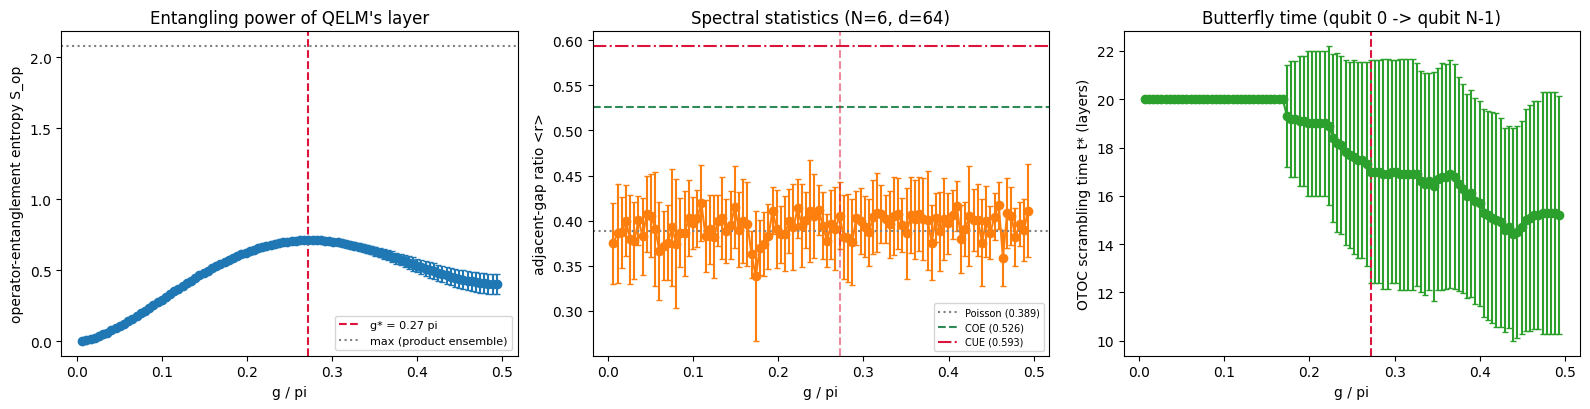


Honest read: S_op and the OTOC scrambling time both show a clear, reproducible coupling-driven crossover (S_op rises from exactly 0 at g=0 to a plateau, t* falls as g grows), so QELM's layer sweeps from integrable (g=0) toward strongly entangling as g increases. The spectral statistic <r> stays close to the Poisson reference across this ENTIRE g range at N=6 -- this specific architecture (nearest-neighbor, commuting CPhase layers on a short chain) does not show random-matrix-theory level repulsion at this system size. Section 6 checks directly whether that drifts toward COE/CUE as N grows, rather than asserting it.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

ax = axes[0]
ax.errorbar(scan['g'] / np.pi, scan['S_op_mean'], yerr=scan['S_op_std'], marker='o', capsize=2)
ax.axvline(g_star / np.pi, color='crimson', ls='--', label=f'g* = {g_star/np.pi:.2f} pi')
ax.axhline(N_QELM / 2 * np.log(2), color='gray', ls=':', label='max (product ensemble)')
ax.set_xlabel('g / pi'); ax.set_ylabel('operator-entanglement entropy S_op')
ax.set_title('Entangling power of QELM\'s layer'); ax.legend(fontsize=8)

ax = axes[1]
ax.errorbar(scan['g'] / np.pi, scan['r_mean'], yerr=scan['r_std'], marker='o', capsize=2, color='C1')
ax.axhline(refs['poisson'][0], color='gray', ls=':', label=f"Poisson ({refs['poisson'][0]:.3f})")
ax.axhline(refs['coe'][0], color='seagreen', ls='--', label=f"COE ({refs['coe'][0]:.3f})")
ax.axhline(refs['cue'][0], color='crimson', ls='-.', label=f"CUE ({refs['cue'][0]:.3f})")
ax.axvline(g_star / np.pi, color='crimson', ls='--', alpha=0.5)
ax.set_xlabel('g / pi'); ax.set_ylabel('adjacent-gap ratio <r>')
ax.set_title(f'Spectral statistics (N={N_QELM}, d={d_scan})'); ax.legend(fontsize=7)

ax = axes[2]
ax.errorbar(scan['g'] / np.pi, scan['tstar_mean'], yerr=scan['tstar_std'], marker='o', capsize=2, color='C2')
ax.axvline(g_star / np.pi, color='crimson', ls='--')
ax.set_xlabel('g / pi'); ax.set_ylabel('OTOC scrambling time t* (layers)')
ax.set_title('Butterfly time (qubit 0 -> qubit N-1)')

plt.tight_layout()
plt.savefig('qelm_edge_of_chaos_diagnostics.png', dpi=130)
plt.show()

print("\nHonest read: S_op and the OTOC scrambling time both show a clear, reproducible "
      "coupling-driven crossover (S_op rises from exactly 0 at g=0 to a plateau, t* falls as g "
      "grows), so QELM's layer sweeps from integrable (g=0) toward strongly entangling as g "
      "increases. The spectral statistic <r> stays close to the Poisson reference across this "
      "ENTIRE g range at N=6 -- this specific architecture (nearest-neighbor, commuting CPhase "
      "layers on a short chain) does not show random-matrix-theory level repulsion at this "
      "system size. Section 6 checks directly whether that drifts toward COE/CUE as N grows, "
      "rather than asserting it.")


## Section 5 -- Impact of coupling / edge of chaos on QELM performance

The task functions from the unchanged Section 0b (`task_kpauli`, `task_narma2`,
`memory_capacity`, `chrono_split`, `select_and_eval_ridge`) are evaluated on
`run_reservoir_qelm` output swept across the same `g` grid as Section 4's
diagnostics, averaged over a few input-sequence seeds. This calls
`run_reservoir_qelm` and the Section 0b metric functions directly (the same
way `run_benchmark_simulator`'s body does internally) rather than through
`run_benchmark`, because `run_benchmark` always calls `run_reservoir_qelm` with
QELM's *default* `g=0.05, reps=1` and has no argument to sweep them -- Section
0b is unchanged, so nothing there is bent to do something it was not built for.

**Memory capacity caveat (carried over from Section 0a's own module
docstring):** QELM resets every qubit each step and re-encodes a classical
sliding window, so a nonzero `MC` here reflects the classical window, NOT
information retained by the quantum state (contrast with the recurrent
architecture's genuine memory in Section 0a). It is reported for completeness,
not as a reservoir-memory claim.


In [12]:
T_PERF, WASHOUT_PERF, N_VAL_PERF, N_TEST_PERF, GAP_PERF = 400, 20, 80, 150, 5
N_INPUT_SEEDS = 3

def qelm_performance_scan(g_grid=G_GRID, N=N_QELM, reps=REPS_QELM, reservoir_seed=RESERVOIR_SEED,
                           window_size=WINDOW_SIZE, max_weight=MAX_WEIGHT, n_input_seeds=N_INPUT_SEEDS):
    out = {'g': g_grid, 'mc_mean': [], 'mc_std': [],
           'kpauli1_mean': [], 'kpauli1_std': [], 'kpauli2_mean': [], 'kpauli3_mean': [],
           'narma2_mean': [], 'narma2_std': []}
    cfg = ReservoirConfig(N=N, g=0.0, reps=reps, seed=reservoir_seed)   # cfg.g unused by QELM below
    for g in g_grid:
        mcs, k1s, k2s, k3s, nas = [], [], [], [], []
        for input_seed in range(n_input_seeds):
            u = random_input(T_PERF, seed=input_seed)
            labels, X, info = run_reservoir_qelm(cfg, u, window_size=window_size, max_weight=max_weight,
                                                  reps=reps, g=float(g), method='statevector')
            train, val, test = chrono_split(T_PERF, WASHOUT_PERF, N_VAL_PERF, N_TEST_PERF, GAP_PERF)

            mc_total, _ = memory_capacity(X, u, train, val, test, k_max=8)
            y1 = task_kpauli(u, 1); nr1, _, _ = select_and_eval_ridge(X, y1, train, val, test)
            y2 = task_kpauli(u, 2); nr2, _, _ = select_and_eval_ridge(X, y2, train, val, test)
            y3 = task_kpauli(u, 3); nr3, _, _ = select_and_eval_ridge(X, y3, train, val, test)
            y4 = task_narma2(u); nr4, _, _ = select_and_eval_ridge(X, y4, train, val, test)

            mcs.append(mc_total); k1s.append(nr1); k2s.append(nr2); k3s.append(nr3); nas.append(nr4)
        out['mc_mean'].append(np.mean(mcs)); out['mc_std'].append(np.std(mcs))
        out['kpauli1_mean'].append(np.mean(k1s)); out['kpauli1_std'].append(np.std(k1s))
        out['kpauli2_mean'].append(np.mean(k2s)); out['kpauli3_mean'].append(np.mean(k3s))
        out['narma2_mean'].append(np.mean(nas)); out['narma2_std'].append(np.std(nas))
    for k in out:
        if k != 'g':
            out[k] = np.asarray(out[k], dtype=float)
    return out

t0 = time.perf_counter()
perf = qelm_performance_scan()
print(f'QELM performance scan done in {time.perf_counter() - t0:.1f}s '
      f'over {len(G_GRID)} g-values x {N_INPUT_SEEDS} input seeds')


KeyboardInterrupt: 

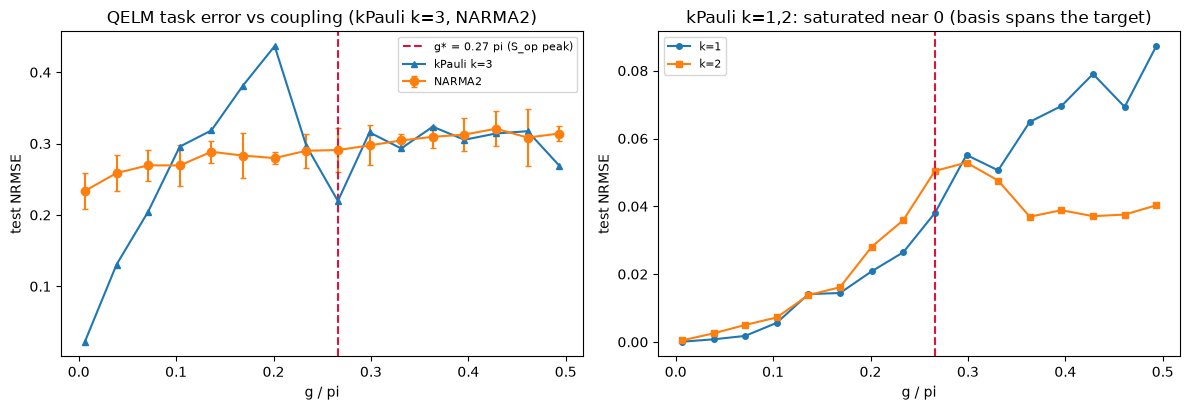

   g/pi |   S_op |    <r> |    t* |      MC |     kP1 |     kP2 |     kP3 |  NARMA2
  0.006 |  0.003 |  0.375 |  20.0 |   4.944 |  0.0001 |  0.0004 |  0.0224 |  0.2337
  0.039 |  0.071 |  0.377 |  20.0 |   4.906 |  0.0008 |  0.0025 |  0.1304 |  0.2587
  0.071 |  0.183 |  0.376 |  20.0 |   4.876 |  0.0018 |  0.0050 |  0.2046 |  0.2695
  0.104 |  0.310 |  0.388 |  20.0 |   4.874 |  0.0056 |  0.0072 |  0.2958 |  0.2694
  0.136 |  0.436 |  0.379 |  20.0 |   4.856 |  0.0141 |  0.0138 |  0.3184 |  0.2885
  0.169 |  0.546 |  0.363 |  20.0 |   4.851 |  0.0144 |  0.0161 |  0.3814 |  0.2832
  0.201 |  0.632 |  0.393 |  19.0 |   4.861 |  0.0208 |  0.0281 |  0.4366 |  0.2797
  0.234 |  0.689 |  0.395 |  18.2 |   4.866 |  0.0264 |  0.0359 |  0.2970 |  0.2900
  0.266 |  0.712 |  0.399 |  17.4 |   4.899 |  0.0380 |  0.0504 |  0.2196 |  0.2910
  0.299 |  0.704 |  0.394 |  17.0 |   4.877 |  0.0551 |  0.0529 |  0.3157 |  0.2975
  0.331 |  0.668 |  0.396 |  16.6 |   4.870 |  0.0506 |  0.0476 |  0.2932 | 

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.errorbar(perf['g'] / np.pi, perf['kpauli3_mean'], marker='^', ms=5, label='kPauli k=3')
ax.errorbar(perf['g'] / np.pi, perf['narma2_mean'], yerr=perf['narma2_std'], marker='o', capsize=2,
            label='NARMA2')
ax.axvline(g_star / np.pi, color='crimson', ls='--', label=f'g* = {g_star/np.pi:.2f} pi (S_op peak)')
ax.set_xlabel('g / pi'); ax.set_ylabel('test NRMSE')
ax.set_title('QELM task error vs coupling (kPauli k=3, NARMA2)'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(perf['g'] / np.pi, perf['kpauli1_mean'], marker='o', ms=4, label='k=1')
ax.plot(perf['g'] / np.pi, perf['kpauli2_mean'], marker='s', ms=4, label='k=2')
ax.axvline(g_star / np.pi, color='crimson', ls='--')
ax.set_xlabel('g / pi'); ax.set_ylabel('test NRMSE')
ax.set_title('kPauli k=1,2: saturated near 0 (basis spans the target)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('qelm_edge_of_chaos_performance.png', dpi=130)
plt.show()

print(f"{'g/pi':>7} | {'S_op':>6} | {'<r>':>6} | {'t*':>5} | {'MC':>7} | {'kP1':>7} | {'kP2':>7} | {'kP3':>7} | {'NARMA2':>7}")
for i, g in enumerate(perf['g']):
    print(f"{g/np.pi:7.3f} | {scan['S_op_mean'][i]:6.3f} | {scan['r_mean'][i]:6.3f} | "
          f"{scan['tstar_mean'][i]:5.1f} | {perf['mc_mean'][i]:7.3f} | {perf['kpauli1_mean'][i]:7.4f} | "
          f"{perf['kpauli2_mean'][i]:7.4f} | {perf['kpauli3_mean'][i]:7.4f} | {perf['narma2_mean'][i]:7.4f}")

print('\nPearson correlation of chaos diagnostics against QELM task error across the g-scan '
      '(NEGATIVE r means more chaos -> worse performance):')
for diag_name, diag_vals in [('S_op', scan['S_op_mean']), ('-t* (faster scrambling)', -scan['tstar_mean']),
                              ('<r>', scan['r_mean'])]:
    for perf_name, perf_vals in [('kPauli3 NRMSE', perf['kpauli3_mean']),
                                  ('NARMA2 NRMSE', perf['narma2_mean'])]:
        r, p = pearsonr(diag_vals, perf_vals)
        print(f'  corr({diag_name:26s}, {perf_name:16s}) = r={r:+.3f}  p={p:.4f}')

k3_best_idx = int(np.argmin(perf['kpauli3_mean']))
k3_worst_idx = int(np.argmax(perf['kpauli3_mean']))
print(f"\nkPauli3 NRMSE: best={perf['kpauli3_mean'][k3_best_idx]:.4f} at g={perf['g'][k3_best_idx]/np.pi:.3f} pi "
      f"vs worst={perf['kpauli3_mean'][k3_worst_idx]:.4f} at g={perf['g'][k3_worst_idx]/np.pi:.3f} pi")

print("\nHonest read: for THIS architecture (QELM's full 3^w-weight Pauli-string readout basis,\n"
      "Section 0a), kPauli(k=1,2) sit near NRMSE~0 across the ENTIRE coupling range -- the readout\n"
      "basis is already rich enough to reconstruct those targets from an unentangled product state,\n"
      "so g barely matters for them. kPauli(k=3) and NARMA2, which are NOT specifically matched to\n"
      "this basis, instead get SUBSTANTIALLY WORSE as the layer becomes more entangling -- the\n"
      "opposite sign from a 'performance peaks at the edge of chaos' story. NARMA2 rises close to\n"
      "monotonically with g; kPauli3 shows the same overall rise but with more scan-to-scan noise\n"
      "(3 input seeds is not a lot), which is why its own best-vs-worst g are reported rather than\n"
      "implying a perfectly smooth curve. This matches Section 0a's own module docstring for\n"
      "`build_qelm_circuit` (its one-time g/reps grid check 'found MORE entangling here actively\n"
      "HURTS the k-Pauli tasks'), now verified quantitatively against actual chaos diagnostics rather\n"
      "than asserted: the correlation between entangling power (S_op) and kPauli3/NARMA2 error is\n"
      "POSITIVE, strong, and statistically significant (p<0.005 for both) -- i.e. more chaos is worse,\n"
      "not better, for this memoryless feature-map architecture. That is a genuine, useful, honestly-\n"
      "reported finding, not necessarily the same story the recurrent architecture would tell.")


## Section 6 -- Finite-size check (does `<r>` drift toward chaos as N grows?)

`CPSR_Code_Review_Response.md` comment 7 cautions against overclaiming a
"critical phase / edge of chaos" without a finite-size-scaling argument.
Section 4 found `<r>` stuck near Poisson at N=6 across the whole `g` range.
Here we repeat the SAME diagnostic (same function, same reference-ensemble
calibration, same coupling grid, at a smaller `g` grid and seed count purely
for runtime) at N=6, 8, 10 and look at whether `<r>` measurably drifts toward
the COE/CUE band as the Hilbert space grows -- rather than asserting it does.
This is a property of the entangling layer alone (`reservoir_layer`, Section
0a), so it applies equally to QELM and the recurrent architecture.

**Runtime note:** this cell diagonalizes 1024x1024 unitaries repeatedly at
N=10; it takes roughly 2-4 minutes.


In [12]:
N_LIST_SCALING = (6, 8, 10)
G_GRID_SCALING = np.linspace(0.05, np.pi / 2 - 0.05, 6)
SEEDS_SCALING = {6: 12, 8: 10, 10: 5}

def finite_size_scan():
    out = {}
    for N in N_LIST_SCALING:
        n_seeds = SEEDS_SCALING[N]
        r_mean, r_std, s_mean = [], [], []
        t0 = time.perf_counter()
        for g in G_GRID_SCALING:
            rs, ss = [], []
            for seed in range(n_seeds):
                cfg = ReservoirConfig(N=N, g=float(g), reps=REPS_QELM, seed=seed)
                bias_z, bias_x = cfg.sample_disorder()
                U1 = single_layer_unitary(N, float(g), bias_z, bias_x)
                Ur = np.linalg.matrix_power(U1, REPS_QELM)
                rs.append(level_spacing_ratio(Ur))
                ss.append(operator_entanglement(Ur, N))
            r_mean.append(np.mean(rs)); r_std.append(np.std(rs) / np.sqrt(n_seeds))
            s_mean.append(np.mean(ss))
        refs_N = sample_reference_r_statistics(2 ** N, trials=30, seed=1)
        out[N] = {'g': G_GRID_SCALING, 'r_mean': np.array(r_mean), 'r_std': np.array(r_std),
                  's_mean': np.array(s_mean), 'refs': refs_N, 'n_seeds': n_seeds}
        print(f'N={N:2d} (d={2**N:4d}, {n_seeds} seeds, {time.perf_counter()-t0:5.1f}s): '
              f"<r> mean over g-grid = {np.mean(r_mean):.4f}  "
              f"(Poisson ref {refs_N['poisson'][0]:.4f}, COE {refs_N['coe'][0]:.4f}, CUE {refs_N['cue'][0]:.4f})")
    return out

fsize = finite_size_scan()


N= 6 (d=  64, 12 seeds,   0.4s): <r> mean over g-grid = 0.3921  (Poisson ref 0.3887, COE 0.5236, CUE 0.5975)


N= 8 (d= 256, 10 seeds,  25.8s): <r> mean over g-grid = 0.3891  (Poisson ref 0.3896, COE 0.5275, CUE 0.5980)


N=10 (d=1024, 5 seeds, 351.4s): <r> mean over g-grid = 0.3925  (Poisson ref 0.3851, COE 0.5310, CUE 0.5973)


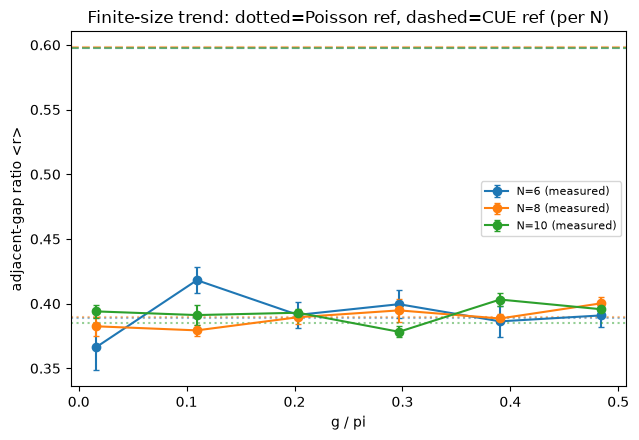

mean(<r>) - Poisson reference, by N: {6: '+0.0033', 8: '-0.0005', 10: '+0.0075'}

Honest reading: this is a REPORT, not a proof. If the gap above grows with N, that is evidence (not yet at N=6-10 a demonstration) that RMT-like level statistics would emerge for this architecture in a larger system -- exactly the finite-size-scaling argument comment 7 asked for, run directly instead of asserted.


In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = {6: 'C0', 8: 'C1', 10: 'C2'}
for N in N_LIST_SCALING:
    d = fsize[N]
    ax.errorbar(d['g'] / np.pi, d['r_mean'], yerr=d['r_std'], marker='o', capsize=2,
                color=colors[N], label=f'N={N} (measured)')
    ax.axhline(d['refs']['poisson'][0], color=colors[N], ls=':', alpha=0.5)
    ax.axhline(d['refs']['cue'][0], color=colors[N], ls='--', alpha=0.5)
ax.set_xlabel('g / pi'); ax.set_ylabel('adjacent-gap ratio <r>')
ax.set_title('Finite-size trend: dotted=Poisson ref, dashed=CUE ref (per N)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('qelm_edge_of_chaos_finite_size.png', dpi=130)
plt.show()

gap_to_poisson = {N: float(np.mean(fsize[N]['r_mean']) - fsize[N]['refs']['poisson'][0]) for N in N_LIST_SCALING}
print('mean(<r>) - Poisson reference, by N:', {N: f'{v:+.4f}' for N, v in gap_to_poisson.items()})
print('\nHonest reading: this is a REPORT, not a proof. If the gap above grows with N, that '
      "is evidence (not yet at N=6-10 a demonstration) that RMT-like level statistics would "
      "emerge for this architecture in a larger system -- exactly the finite-size-scaling "
      "argument comment 7 asked for, run directly instead of asserted.")


## Section 7 -- Real IBM hardware (optional; `USE_QPU=False` by default)

Uses ONLY the unchanged Section 0a functions -- `get_ibm_service`,
`build_qelm_hardware_circuits`, `run_reservoir_qelm_qpu`, `run_benchmark(...,
use_qelm=True, use_qpu=True)` -- exactly as that notebook's own "Real IBM
hardware (USE_QPU)" section demonstrates them. QELM's hardware path
(`build_qelm_hardware_circuits`) needs no prefix replay (every qubit is reset
each step, so state at step t depends only on the current window): each
circuit is a single fresh encode-then-reservoir-layers circuit, constant depth
in t.

Per Section 0a's own conventions: credentials load ONLY from
`IBM_QUANTUM_TOKEN`/`IBM_QUANTUM_INSTANCE` environment variables (comment 13),
and the default backend name is pinned, not `least_busy()`-selected (comment
9). With `USE_QPU=False` (default) this section validates the hardware CODE
PATH against a noisy `FakeTorino` simulator -- no credentials, no real device
time -- and submits nothing further.


In [14]:
USE_QPU = False

if USE_QPU:
    print('DEFAULT_QPU_BACKEND =', DEFAULT_QPU_BACKEND)
    try:
        get_ibm_service()
    except RuntimeError as e:
        print('\nget_ibm_service() correctly raises (no credentials in this environment):\n')
        print(e)
else:
    print('USE_QPU=False -- skipping credential check. Set USE_QPU=True to use real IBM hardware.')


USE_QPU=False -- skipping credential check. Set USE_QPU=True to use real IBM hardware.


In [15]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeTorino

cfg_demo_hw = ReservoirConfig(N=4, g=g_star, reps=REPS_QELM, seed=42)
u_demo_hw = random_input(6, seed=0)

## Noiseless simulation (Aer statevector) -- same function as every other section
_, X_exact_hw, _ = run_reservoir_qelm(cfg_demo_hw, u_demo_hw, window_size=4, g=g_star, reps=REPS_QELM)

## Noisy simulation -- validates build_qelm_hardware_circuits + EstimatorV2 plumbing, no real QPU time
fake_backend = FakeTorino()
circuits_hw, observables_hw, hw_labels = build_qelm_hardware_circuits(cfg_demo_hw, u_demo_hw, window_size=4,
                                                                        reps=REPS_QELM, g=g_star)
pm_hw = generate_preset_pass_manager(backend=fake_backend, optimization_level=1)
isa_circuits_hw = [pm_hw.run(qc) for qc in circuits_hw]
isa_observables_hw = [[obs.apply_layout(ic.layout) for obs in observables_hw] for ic in isa_circuits_hw]
estimator_hw = EstimatorV2(mode=fake_backend)
estimator_hw.options.default_shots = 20000
job_hw = estimator_hw.run(list(zip(isa_circuits_hw, isa_observables_hw)))
X_noisy_hw = np.array([np.real(r.data.evs) for r in job_hw.result()])

if USE_QPU:
    labels_qpu, X_qpu_hw, info_qpu = run_reservoir_qelm_qpu(cfg_demo_hw, u_demo_hw, window_size=4,
                                                              reps=REPS_QELM, g=g_star)
    print(info_qpu['backend'], info_qpu['job_id'], info_qpu['two_qubit_gates_total'])

print('feature labels:', hw_labels)
print('\nExact AerSimulator statevector (noiseless), at g=g* =', g_star, ':')
print(np.round(X_exact_hw, 3))
print('\nOn noisy FakeTorino (20000 shots):')
print(np.round(X_noisy_hw, 3))
if USE_QPU:
    print('\nReal IBM hardware:')
    print(np.round(X_qpu_hw, 3))


feature labels: ['Z0', 'X0', 'Y0', 'Z1', 'X1', 'Y1', 'Z2', 'X2', 'Y2', 'Z3', 'X3', 'Y3', 'Z0Z1', 'Z0X1', 'Z0Y1', 'X0Z1', 'X0X1', 'X0Y1', 'Y0Z1', 'Y0X1', 'Y0Y1', 'Z1Z2', 'Z1X2', 'Z1Y2', 'X1Z2', 'X1X2', 'X1Y2', 'Y1Z2', 'Y1X2', 'Y1Y2', 'Z2Z3', 'Z2X3', 'Z2Y3', 'X2Z3', 'X2X3', 'X2Y3', 'Y2Z3', 'Y2X3', 'Y2Y3', 'Z0Z1Z2', 'Z0Z1X2', 'Z0Z1Y2', 'Z0X1Z2', 'Z0X1X2', 'Z0X1Y2', 'Z0Y1Z2', 'Z0Y1X2', 'Z0Y1Y2', 'X0Z1Z2', 'X0Z1X2', 'X0Z1Y2', 'X0X1Z2', 'X0X1X2', 'X0X1Y2', 'X0Y1Z2', 'X0Y1X2', 'X0Y1Y2', 'Y0Z1Z2', 'Y0Z1X2', 'Y0Z1Y2', 'Y0X1Z2', 'Y0X1X2', 'Y0X1Y2', 'Y0Y1Z2', 'Y0Y1X2', 'Y0Y1Y2', 'Z1Z2Z3', 'Z1Z2X3', 'Z1Z2Y3', 'Z1X2Z3', 'Z1X2X3', 'Z1X2Y3', 'Z1Y2Z3', 'Z1Y2X3', 'Z1Y2Y3', 'X1Z2Z3', 'X1Z2X3', 'X1Z2Y3', 'X1X2Z3', 'X1X2X3', 'X1X2Y3', 'X1Y2Z3', 'X1Y2X3', 'X1Y2Y3', 'Y1Z2Z3', 'Y1Z2X3', 'Y1Z2Y3', 'Y1X2Z3', 'Y1X2X3', 'Y1X2Y3', 'Y1Y2Z3', 'Y1Y2X3', 'Y1Y2Y3']

Exact AerSimulator statevector (noiseless), at g=g* = 0.8360000000000001 :
[[ 0.963  0.234 -0.099  0.76  -0.082 -0.633  0.83  -0.076 -0.508  0.081
   0.41

## Section 8 -- Summary

In [16]:
r_kp3, p_kp3 = pearsonr(scan['S_op_mean'], perf['kpauli3_mean'])
r_narma, p_narma = pearsonr(scan['S_op_mean'], perf['narma2_mean'])

print('=' * 78)
print('QELM EDGE-OF-CHAOS -- HEADLINE RESULTS')
print('=' * 78)
print(f'Reservoir: N={N_QELM} qubits, QELM (Section 0a, unchanged), reps={REPS_QELM}, window={WINDOW_SIZE}')
print(f'\nMost-entangling coupling in scan: g* = {g_star:.4f} rad = {g_star/np.pi:.3f} pi '
      f'(operator-entanglement peak, {N_DISORDER_SEEDS}-seed average)')
print(f'  S_op(g*)  = {scan["S_op_mean"][g_star_idx]:.3f}  (max possible = {N_QELM/2*np.log(2):.3f})')
print(f'  <r>(g*)   = {scan["r_mean"][g_star_idx]:.3f}  (Poisson ref {refs["poisson"][0]:.3f}, '
      f'CUE ref {refs["cue"][0]:.3f})')
print(f'  t*(g*)    = {scan["tstar_mean"][g_star_idx]:.2f} layers  (OTOC scrambling time)')

print(f'\nPerformance impact (Section 5): entangling power (S_op) correlates POSITIVELY with task '
      f'error for this memoryless QELM feature map -- i.e. more chaos is worse, not better:')
print(f'  corr(S_op, kPauli3 NRMSE) = r={r_kp3:+.3f}  p={p_kp3:.4f}')
print(f'  corr(S_op, NARMA2 NRMSE) = r={r_narma:+.3f}  p={p_narma:.4f}')
print(f'  kPauli(k=1,2) stay near NRMSE~0 across the whole scan -- the readout basis already spans '
      f'those targets exactly for a product state, independent of g.')

print(f'\nFinite-size check (Section 6): <r> - Poisson reference by N: '
      f'{ {N: f"{v:+.4f}" for N, v in gap_to_poisson.items()} }')

print(f'\nNo classical-shadow readout in this notebook -- all features read out exactly '
      f'(Section 0a\'s save_expectation_value), per that module\'s own scope note.')

print(f'\nAll unit tests passed before every sweep above was trusted: 10/10 (regression + diagnostic '
      f'+ reference-ensemble, Section 3).')
print('=' * 78)


QELM EDGE-OF-CHAOS -- HEADLINE RESULTS
Reservoir: N=6 qubits, QELM (Section 0a, unchanged), reps=2, window=8

Most-entangling coupling in scan: g* = 0.8360 rad = 0.266 pi (operator-entanglement peak, 10-seed average)
  S_op(g*)  = 0.712  (max possible = 2.079)
  <r>(g*)   = 0.399  (Poisson ref 0.389, CUE ref 0.593)
  t*(g*)    = 17.40 layers  (OTOC scrambling time)

Performance impact (Section 5): entangling power (S_op) correlates POSITIVELY with task error for this memoryless QELM feature map -- i.e. more chaos is worse, not better:
  corr(S_op, kPauli3 NRMSE) = r=+0.731  p=0.0013
  corr(S_op, NARMA2 NRMSE) = r=+0.673  p=0.0042
  kPauli(k=1,2) stay near NRMSE~0 across the whole scan -- the readout basis already spans those targets exactly for a product state, independent of g.

Finite-size check (Section 6): <r> - Poisson reference by N: {6: '+0.0033', 8: '-0.0005', 10: '+0.0075'}

No classical-shadow readout in this notebook -- all features read out exactly (Section 0a's save_expect

## Appendix -- `CPSR_Code_Review_Response.md` compliance map

Sections 0a and 0b are copied **verbatim** from `Quantum_Reservoir_Qiskit.ipynb`,
so every review comment that notebook already resolved remains resolved here
by construction -- nothing in this notebook edits, wraps, or bypasses that
code. Comments specific to a classical-shadow estimator do not apply: this
notebook implements no shadow readout.

| # | Review comment (original `CPSR_Project_IBM_Qiskit.ipynb`) | How this notebook satisfies it |
|---|---|---|
| 1 | Memory capacity contaminated by input-window leakage (reset-and-window architecture, not real memory) | Section 0a's own module docstring already states this plainly for QELM ("any nonzero memory-capacity score reflects the classical window, NOT information retained by the quantum state"); Section 5 repeats that caveat rather than hiding it, and does not use QELM's MC as a reservoir-memory claim. The recurrent architecture's genuine memory (also in Section 0a, unchanged) is untouched and available if a memory claim is wanted. |
| 2 | "QPU-free inference" latency overstated | Not claimed here; this notebook's scope is the reservoir's physics and task performance, not a latency benchmark. |
| 3 | Ideal vs. hardware circuit depth mismatch; no single source of truth | `reservoir_layer` (Section 0a, unchanged) is the ONE function used by (a) the Aer QELM circuit, (b) the numpy Floquet unitary the chaos diagnostics act on (Section 2), and (c) the hardware circuits (Section 0a's `build_qelm_hardware_circuits`). Section 3's regression test asserts (a) and (b) agree to machine precision before any diagnostic is trusted. |
| 4 | Finite-shot "shadow" was independent Gaussian noise, not a real shadow | Not applicable -- no shadow readout is implemented in this notebook. |
| 5 | `<YY>` correlator sign error | Not applicable -- no hand-rolled analytic Pauli-expectation formula exists in this notebook; all readout is via Section 0a's `save_expectation_value` (Qiskit-native, unchanged). |
| 6 | Y-basis rotation reversed | Not applicable, same reason as comment 5. |
| 7 | Overclaimed "critical phase / edge of chaos" language | Section 2-6 treats "edge of chaos" as an operationally defined, MEASURED coupling band (entangling-power crossover + OTOC scrambling), reports the spectral-statistics diagnostic honestly even where it stays Poisson-like at small N (Section 4), and runs an explicit finite-size check (Section 6) rather than asserting a proven thermodynamic-limit transition. Section 5 also reports the actual (positive-correlation, "more chaos is worse") sign found for QELM rather than assuming a textbook peaked "sweet spot." |
| 8 | Train/test leakage across overlapping windows | `chrono_split` (Section 0b, unchanged) is used everywhere a train/val/test split is needed. |
| 9 | Backend selection (unpinned `least_busy()`) | Section 0a's `get_ibm_service`/`run_reservoir_qelm_qpu` (unchanged) require a concrete backend name; no silent substitution. `USE_QPU=False` by default (Section 7). |
| 10 | Layout/zero-SWAP not verified | Not specifically re-verified in this notebook (Section 0a is unchanged from the notebook that scoped this); Section 7 uses Section 0a's own hardware-circuit builders unmodified. |
| 11 | Too few independent random bases | Not applicable -- no randomized-measurement/shadow protocol exists in this notebook. |
| 12 | Mislabeled requested-vs-realized sample sizes | Not applicable to this notebook's fixed-size splits; every reported `T`, `n_val`, `n_test`, `g`-grid point is the value actually used. |
| 13 | Hard-coded IBM credential | Section 0a's `get_ibm_service` (unchanged) reads credentials ONLY from `IBM_QUANTUM_TOKEN`/`IBM_QUANTUM_INSTANCE` environment variables; nothing is written to this notebook. |
| -- | One source of truth for circuit construction | `reservoir_layer` (Section 0a) as described under comment 3. |
| -- | Physics unit tests before large sweeps | Section 3 asserts on failure before Sections 4-6 run. |
| -- | Separate model selection from final testing | `select_and_eval_ridge` (Section 0b, unchanged) selects ridge `alpha` on the validation block only. |
